# Dự đoán số lượt thuê xe theo giờ dựa trên điều kiện thực tế

## 0. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Đọc dữ liệu

In [2]:
df = pd.read_csv("./datas/SeoulBikeData.csv",encoding="cp1252")

In [3]:
df.shape

(8760, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [5]:
df.tail(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [6]:
df.head(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [7]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [8]:
df['Hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

- Chú thích:
    - `Date`: Ngày
    - `Rented Bike Count`: Số lượng xe đạp được thuê trong khung giờ đó.
    - `Hour`: Giờ trong ngày từ 0 - 23
    - `Temperature`: Nhiệt độ theo độ C
    - `Humidity`: Độ ẩm tương đối của không khí (%).
    - `Wind speed`: Tốc độ gió (m/s).
    - `Visibility`: Tầm nhìn xa (đơn vị 10m; ví dụ 2000 tương ứng 20 km).
    - `Dew point temperature`: Nhiệt độ điểm sương (°C) — ngưỡng nhiệt độ mà hơi nước ngưng tụ thành đọng sương.
    - `Solar Radiation (MJ/m2)`: Cường độ bức xạ mặt trời ($MJ/m^2$).
    - `Rainfall(mm)`: Lượng mưa đo được trong giờ đó
    - `Snowfall`: Lượng tuyết rơi đo được trong giờ đó (cm).
    - `Seasons`: Mùa trong năm
    - `Holiday`: Phân loại ngày nghỉ lễ
    - `Functioning Day`: trạng thái hoạt động của hệ thống

## 2. Sữ lí data căn bản

In [9]:
# ép kiểu date thành datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [10]:
# ép season thành category
df['Seasons'] = df['Seasons'].astype('category')

In [11]:
# Ép Holiday thành category
df['Holiday'] = df["Holiday"].map(lambda x: 0 if x =="No Holiday" else 1)
df['Holiday'] = df['Holiday'].astype('category')

In [12]:
# Ép Functioning Day thành category
df["Functioning Day"] = df["Functioning Day"].map(lambda x: 0 if x =="No" else 1)
df['Functioning Day'] = df['Functioning Day'].astype('category')

In [13]:
# Đổi tên cho columns
columns_new = ['date','rented_bike_count','hour','temperature','humidity','wind_speed','visibility','dew_point_temperature','solar_radiation','rainfall','snowfall','seasons','holiday','functioning_day']

In [14]:
df.columns = columns_new

In [15]:
# Tạo thêm column feature
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['date'].dt.weekday>5

# as weekday,is_weekend,hour thành category
df['weekday'] = df['weekday'].astype('category')
df['is_weekend'] = df['is_weekend'].astype('category')
df['hour'] = df['hour'].astype('category')
df['month'] = df['month'].astype('category')

In [16]:
import pandas as pd
import numpy as np
def check_null(df):
    print("=" * 60)
    print("2. KIỂM TRA VALUE THIẾU (NULL / MISSING VALUES)")
    print("=" * 60)
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100

    null_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage (%)': null_pct.round(2),
        'Data Type': df.dtypes
    })

    # Chỉ hiển thị các cột có chứa Null (hoặc báo nếu sạch null)
    cols_with_null = null_df[null_df['Null Count'] > 0]
    if len(cols_with_null) == 0:
        print("=> Tuyệt vời! Không có cột nào bị thiếu dữ liệu (No Nulls).\n")
    else:
        print(cols_with_null)

check_null(df)

2. KIỂM TRA VALUE THIẾU (NULL / MISSING VALUES)
=> Tuyệt vời! Không có cột nào bị thiếu dữ liệu (No Nulls).



In [17]:
def check_duplication(df):
    print("=" * 60)
    print("1. KIỂM TRA DỮ LIỆU TỔNG QUAN & DUPLICATES")
    print("=" * 60)
    total_rows, total_cols = df.shape
    duplicate_count = df.duplicated().sum()
    duplicate_pct = (duplicate_count / total_rows) * 100

    print(f"- Tổng số dòng (Rows): {total_rows}")
    print(f"- Tổng số cột (Columns): {total_cols}")
    print(f"- Số dòng trùng lặp (Duplicates): {duplicate_count} ({duplicate_pct:.2f}%)\n")

check_duplication(df)

1. KIỂM TRA DỮ LIỆU TỔNG QUAN & DUPLICATES
- Tổng số dòng (Rows): 8760
- Tổng số cột (Columns): 17
- Số dòng trùng lặp (Duplicates): 0 (0.00%)



In [18]:
def check_outlier(df, outlier_factor=1.5):
    print("=" * 60)
    print(f"3. KIỂM TRA OUTLIERS (IQR Factor = {outlier_factor})")
    print("=" * 60)
    num_cols = df.select_dtypes(include=[np.number]).columns

    outlier_list = []
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (outlier_factor * IQR)
        upper_bound = Q3 + (outlier_factor * IQR)

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100

        outlier_list.append({
            'Column': col,
            'Outlier Count': outlier_count,
            'Percentage (%)': round(outlier_pct, 2),
            'Min Value': df[col].min(),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Max Value': df[col].max()
        })

    outlier_df = pd.DataFrame(outlier_list)
    print(outlier_df.to_string(index=False))

check_outlier(df)


3. KIỂM TRA OUTLIERS (IQR Factor = 1.5)
               Column  Outlier Count  Percentage (%)  Min Value  Lower Bound  Upper Bound  Max Value
    rented_bike_count            158            1.80        0.0     -1120.38      2376.62    3556.00
          temperature              0            0.00      -17.8       -25.00        51.00      39.40
             humidity              0            0.00        0.0        -6.00       122.00      98.00
           wind_speed            161            1.84        0.0        -1.20         4.40       7.40
           visibility              0            0.00       27.0      -650.00      3590.00    2000.00
dew_point_temperature              0            0.00      -30.6       -33.95        44.05      27.20
      solar_radiation            641            7.32        0.0        -1.40         2.33       3.52
             rainfall            528            6.03        0.0         0.00         0.00      35.00
             snowfall            443            5.0

## 3. Phân tích EDA

### 3.1 Phân tích đơn biến

#### 3.1.1 Phân phối các biến số

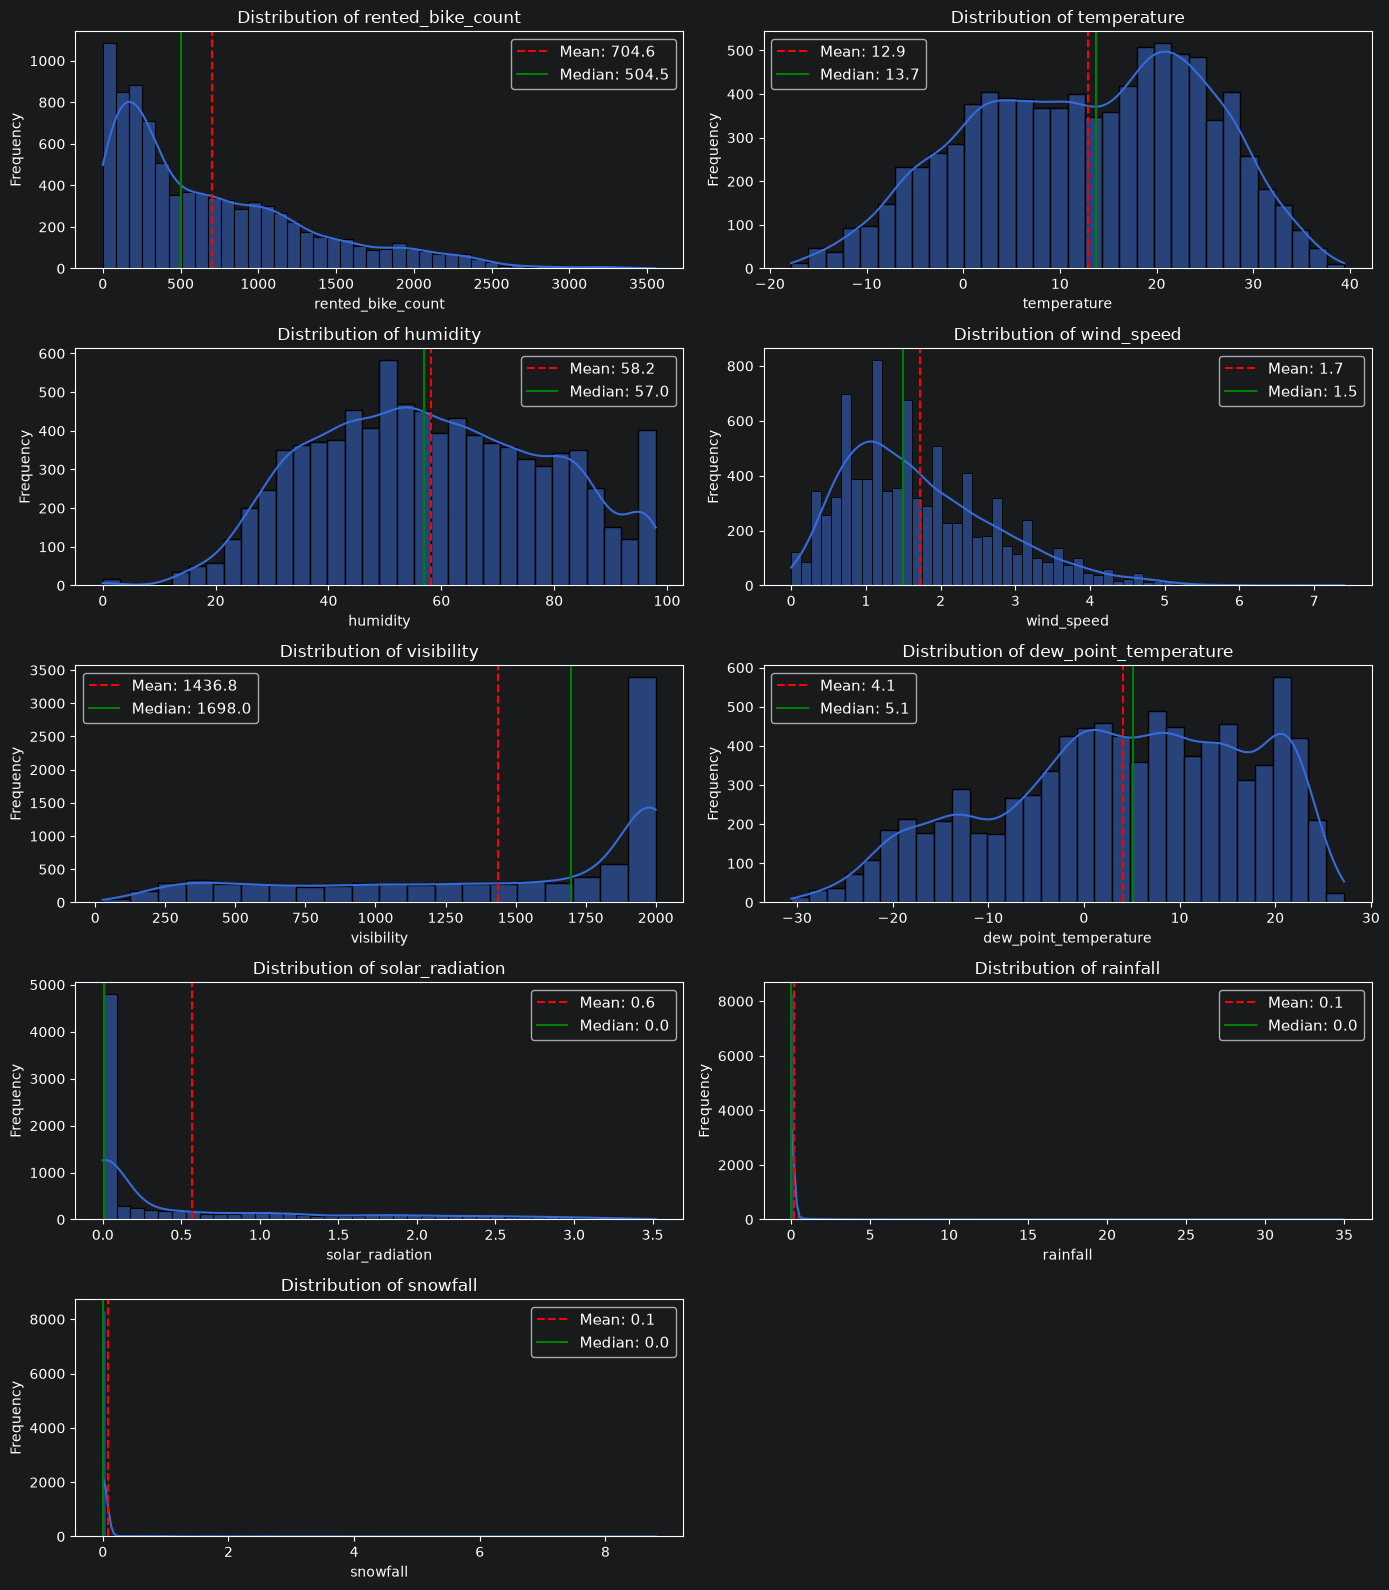

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    # Thêm đường thẳng thể hiện Mean và Median
    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=11)
# Xóa subplot dư
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

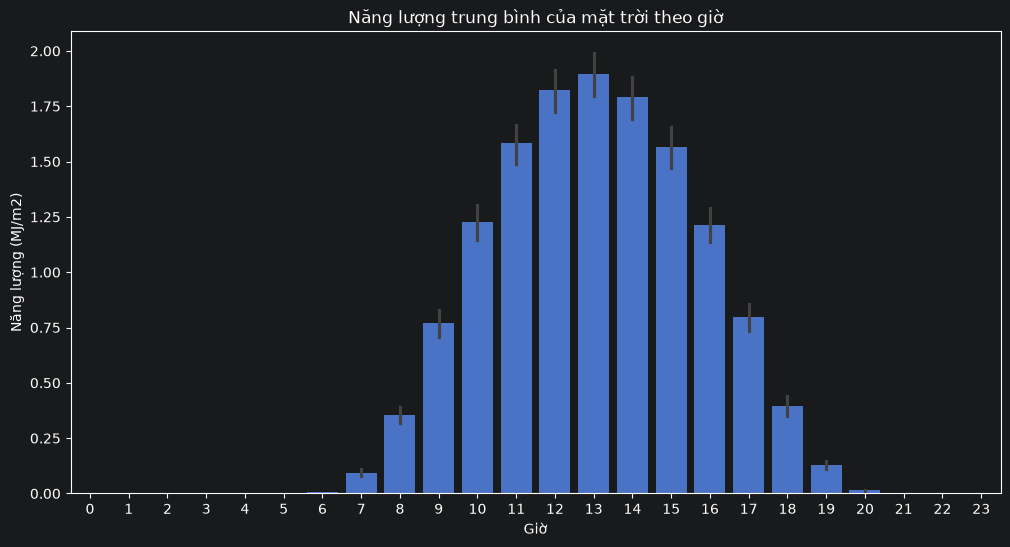

In [20]:
fig = plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x='hour',
    y='solar_radiation'
)
plt.title("Năng lượng trung bình của mặt trời theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Năng lượng (MJ/m2)")
plt.tight_layout
plt.show()

##### chú thích:
- `temperature`, `humidity`, `dew_point_temperature` phân phối chuẩn
- `rented_bike_count`, `wind_speed`, `visibility` Phân phối rất lệch
- `snowfall`, `rainfall` Phân phối rất lệch bởi vì ko phải lúc nào cũng có mưa có tuyết phần lơn dữ liệu là 0
- `solar_radiation` Phân phối dữ liệu rất lệch về phía bên phải bởi vì phần lớn là óc giá trị không từ 9 giờ tối đến 6 giờ sang vì lúc đó ko có mặt trời nên giá trị của năng lượng bằng 0

#### 3.1.2 Phân phối các biến phân loại

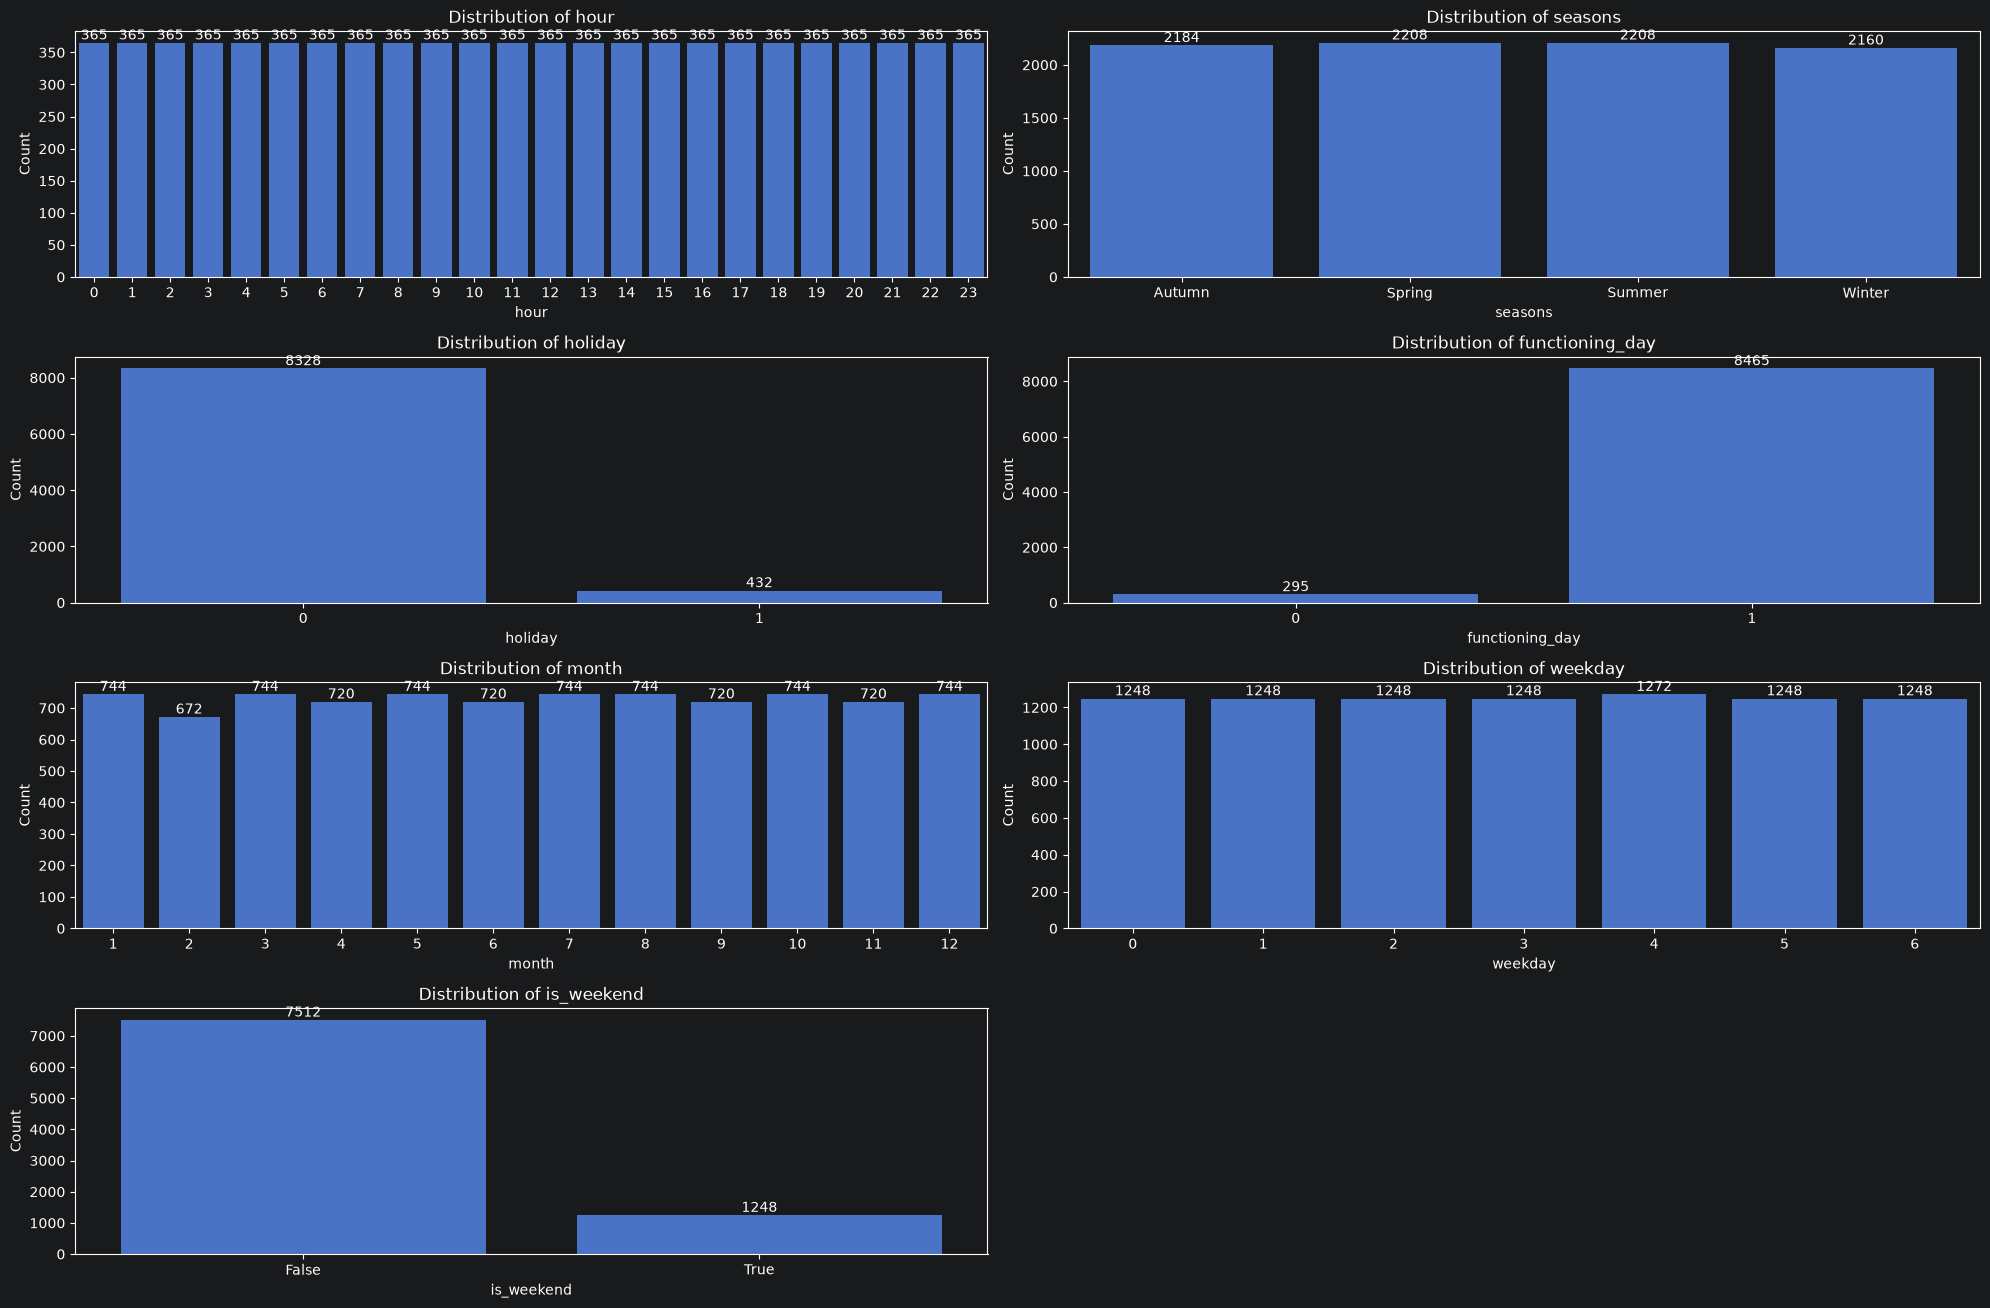

In [21]:
# =========================
# 2. Categorical Variables
# =========================

categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

fig, axes = plt.subplots(5, 2, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    # Hiển thị số lượng trên từng cột
    for container in axes[i].containers:
        axes[i].bar_label(container)

# Xóa subplot dư
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

##### chú thích:
- `holiday`, `functioning_day`, `is_weekend` Phân phối vô cùng hợp lí với ý nghĩa của cột
- `weekday`, `month`, `hour`, `season` Theo quy luật rồi nên phân phôi rất chuẩn

### 3.2 Phân tích đa biến

#### 3.2.1 Scatter plot: Rented Bike Count vs từng numerical feature

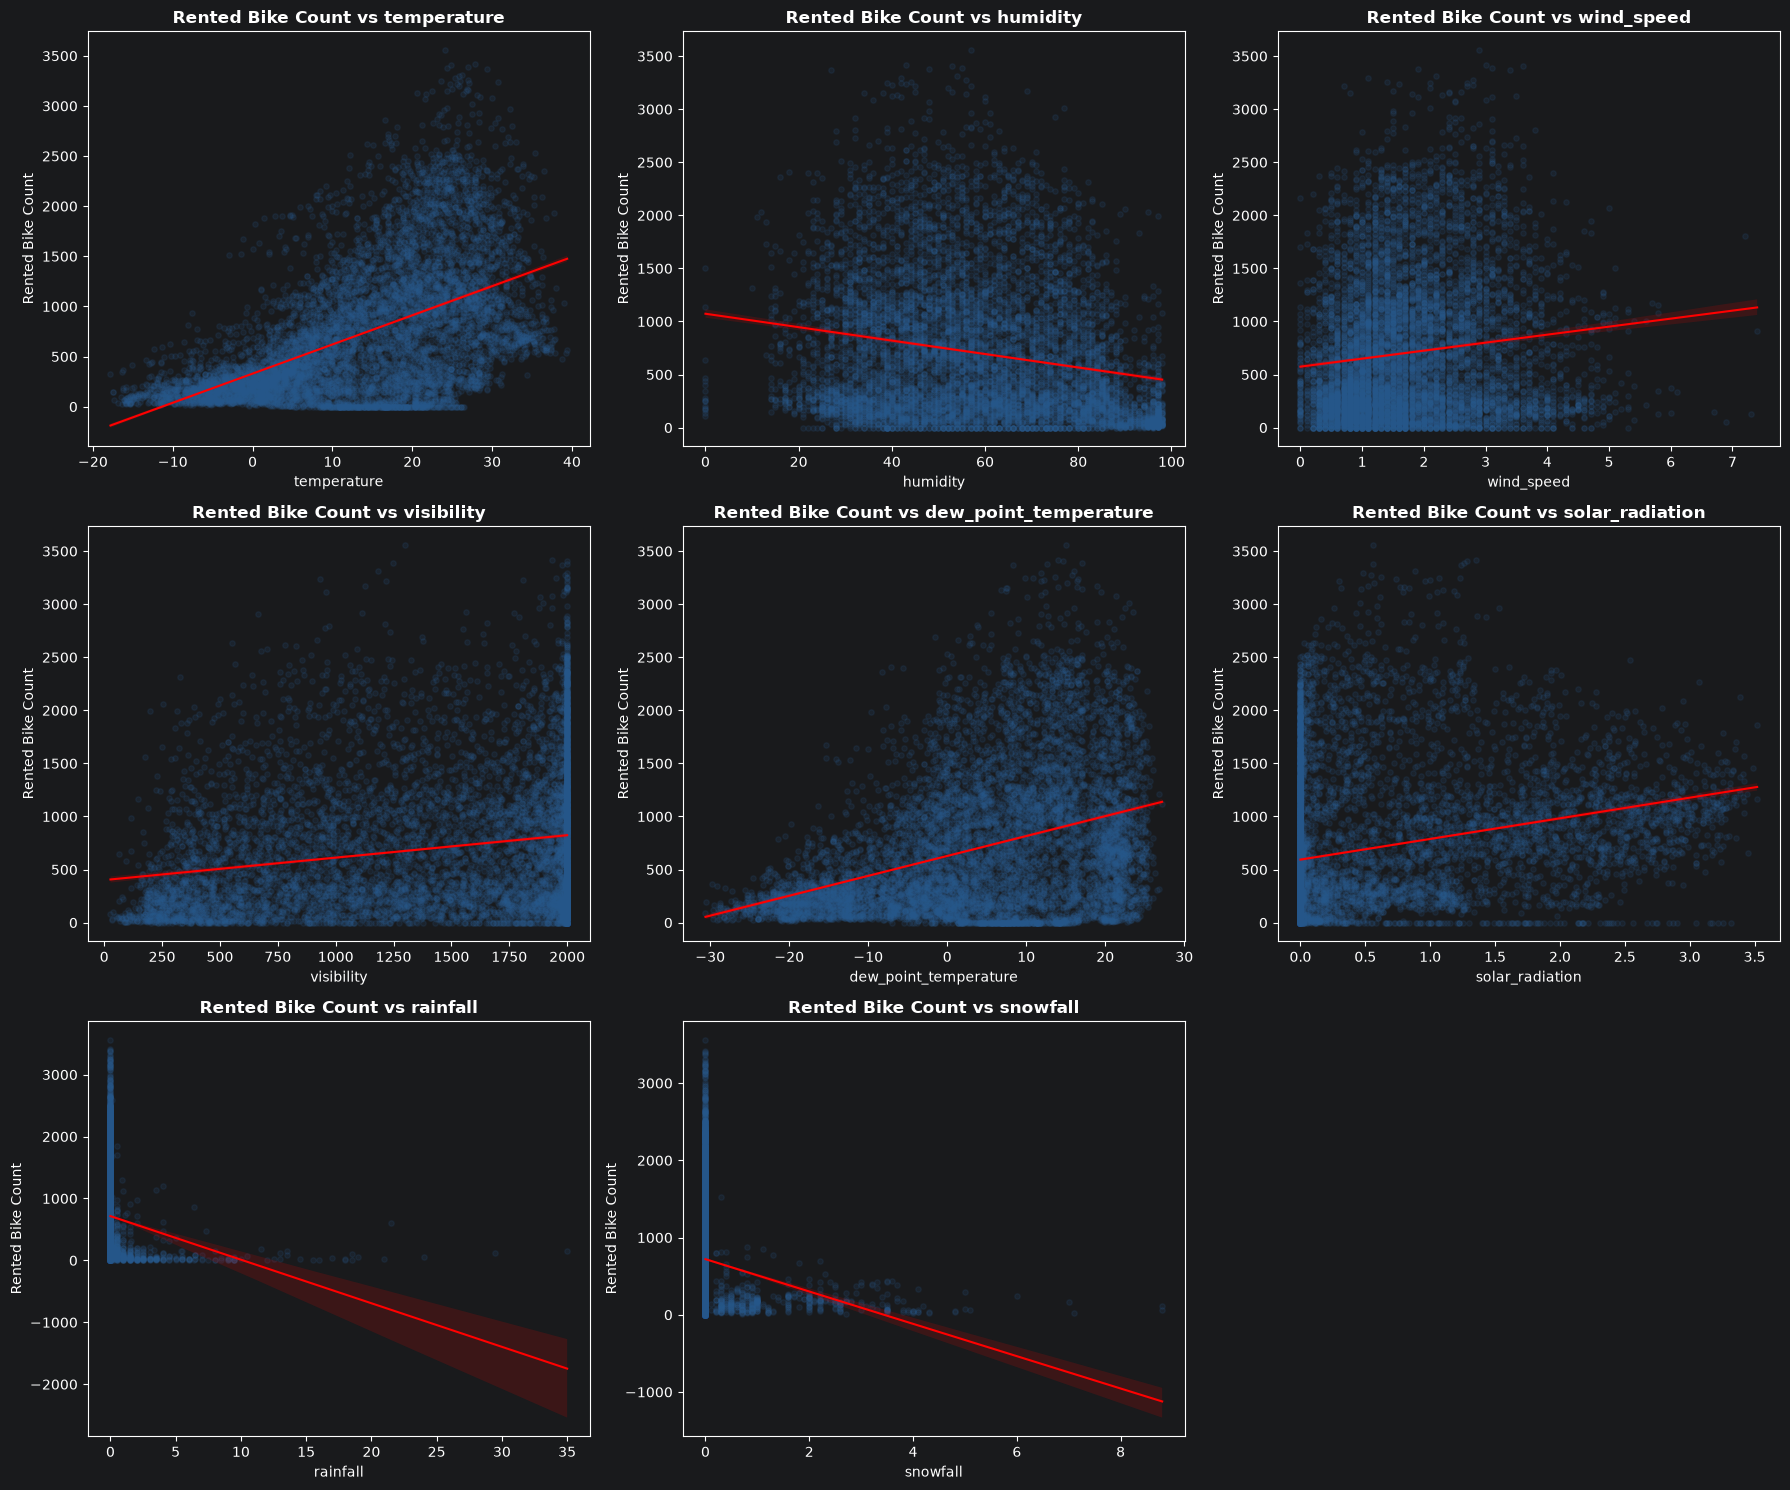

In [22]:

# 1. Lấy danh sách các biến số (loại trừ cột Target)
num_cols_not_target = [num_col for num_col in numerical_cols if num_col not in ['rented_bike_count']]

# 2. Cấu hình lưới subplots (3 cột mỗi hàng)
n_cols = 3
n_rows = (len(num_cols_not_target) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 3. Vẽ Scatter Plot + Regression line cho từng biến số
for i, col in enumerate(num_cols_not_target):
    sns.regplot(
        data=df,
        x=col,
        y="rented_bike_count",
        ax=axes[i],
        scatter_kws={"alpha": 0.15, "color": "#2b5c8f", "s": 15},  # Đặt alpha mỏng vì data 8760 dòng khá dày
        line_kws={"color": "red", "linewidth": 1.5},  # Đường xu hướng màu đỏ
    )
    axes[i].set_title(f"Rented Bike Count vs {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Rented Bike Count", fontsize=10)

# 4. Ẩn các ô biểu đồ thừa (nếu số lượng biến không chia hết cho 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Chú thích:
    - Thông qua biểu đồ heatmap ta có thể thấy đc biến target của ta có tính tương quan với biên `temperature` và `dew_point_temperature`

#### 3.4.3 Boxplot: Rented Bike Count theo Seasons, Holiday, Functioning Day

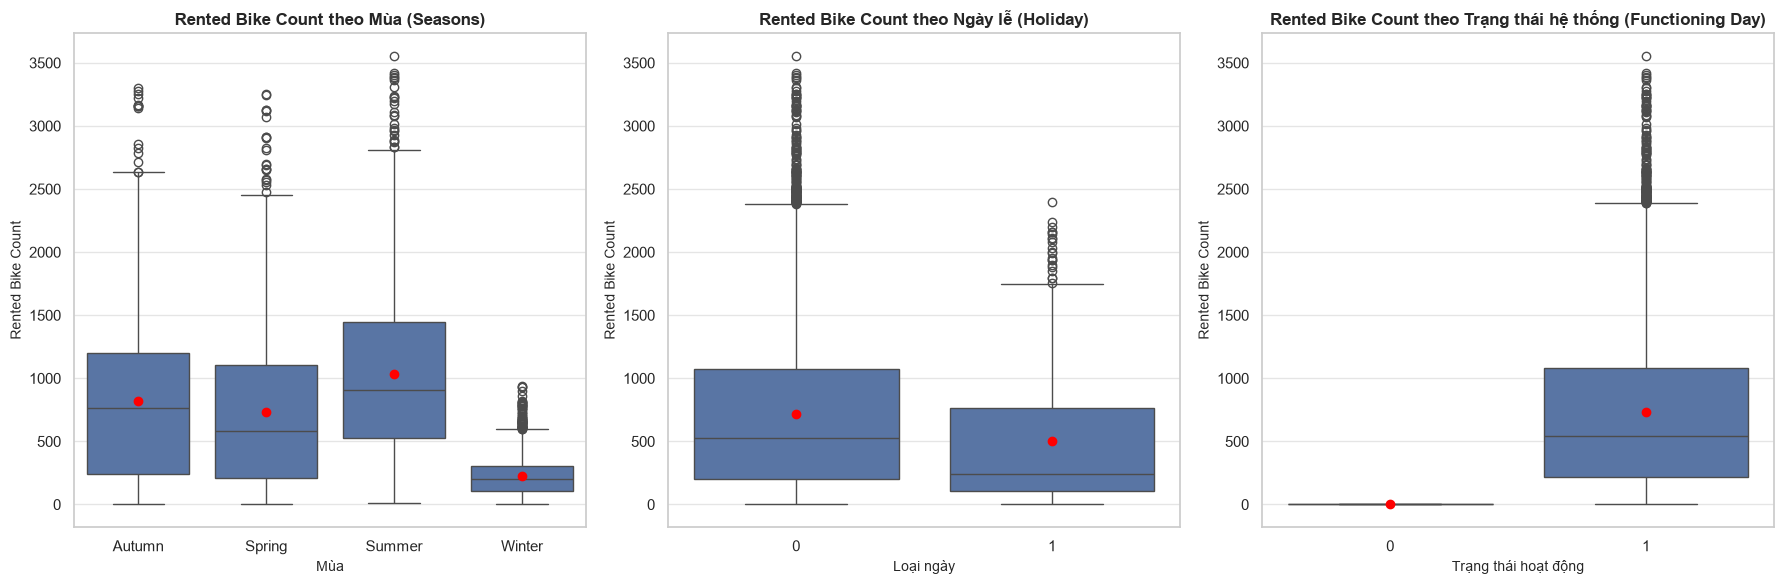

In [23]:

# Cấu hình phong cách đồ họa
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot theo Seasons
sns.boxplot(
    data=df,
    x="seasons",
    y="rented_bike_count",
    ax=axes[0],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[0].set_title(
    "Rented Bike Count theo Mùa (Seasons)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Mùa", fontsize=10)
axes[0].set_ylabel("Rented Bike Count", fontsize=10)

# 2. Boxplot theo Holiday
sns.boxplot(
    data=df,
    x="holiday",
    y="rented_bike_count",
    ax=axes[1],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[1].set_title(
    "Rented Bike Count theo Ngày lễ (Holiday)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Loại ngày", fontsize=10)
axes[1].set_ylabel("Rented Bike Count", fontsize=10)

# 3. Boxplot theo Functioning Day
sns.boxplot(
    data=df,
    x="functioning_day",
    y="rented_bike_count",
    ax=axes[2],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)
axes[2].set_title(
    "Rented Bike Count theo Trạng thái hệ thống (Functioning Day)",
    fontsize=12,
    fontweight="bold",
)
axes[2].set_xlabel("Trạng thái hoạt động", fontsize=10)
axes[2].set_ylabel("Rented Bike Count", fontsize=10)

plt.tight_layout()
plt.show()

- Chú thích:
    - Cho tui thấy mùa hề thì sẽ đc thuê nhiều nhất
    - Xe đc thuê với mục đích sài hàng ngày vì ngày lể mượn xe còn ít hơn ngày bình thường
    - Trạng thái hoạt động của hệ thống Nếu dừng là ko có record nào suy ra cột này vô dụng có thể drop

#### 3.2.4 Boxplot: Rented Bike Count theo từng giờ (Hour)

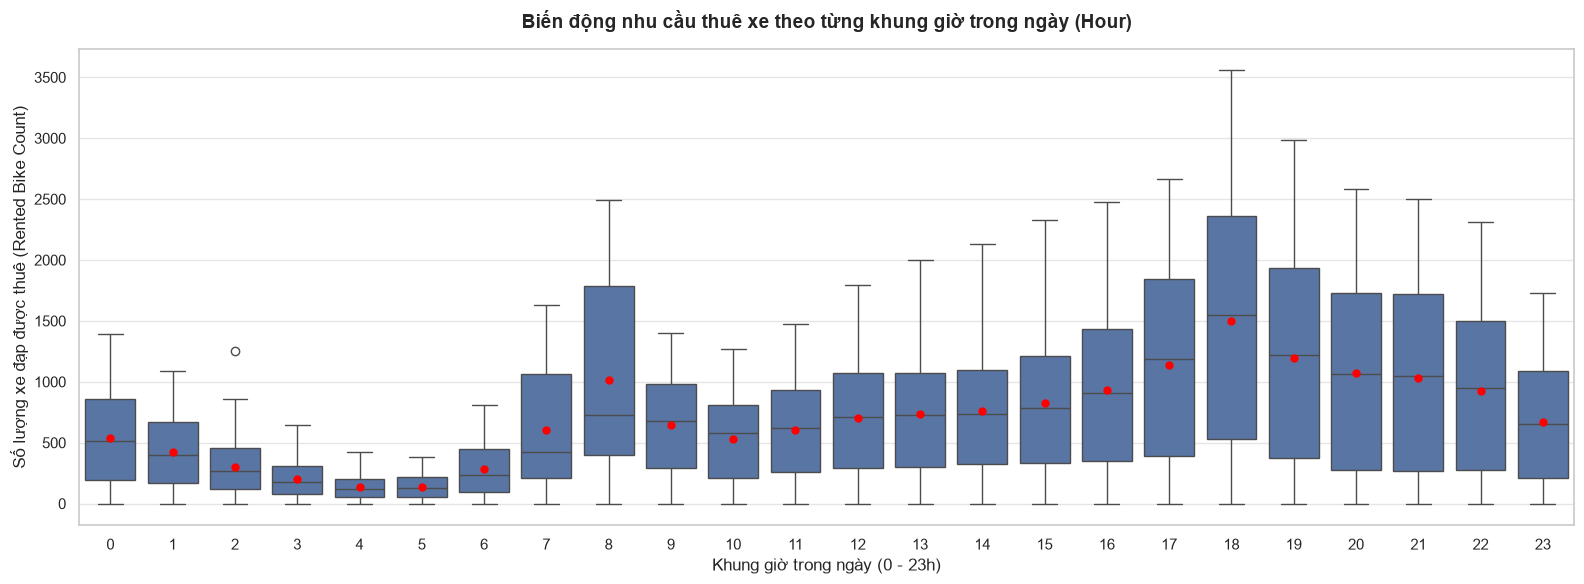

In [24]:
# Cấu hình phong cách đồ họa
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Vẽ Boxplot nhu cầu thuê xe theo từng khung giờ (Hour)
sns.boxplot(
    data=df,
    x="hour",
    y="rented_bike_count",
    legend=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
        "markersize": 5,
    },
)

# Tinh chỉnh tiêu đề và các trục
plt.title(
    "Biến động nhu cầu thuê xe theo từng khung giờ trong ngày (Hour)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Khung giờ trong ngày (0 - 23h)", fontsize=12)
plt.ylabel("Số lượng xe đạp được thuê (Rented Bike Count)", fontsize=12)

plt.tight_layout()
plt.show()

- Chú thích:
    - Biểu đồ cho ta thấy chỉ có 1 outlier ở khung 2 giờ thôi
    - Biến động nhiều nhất là ở khung giờ 8 16 17 10 19 20 21 22 23 còn những khung giờ khác có độ biến động ít hơn zay thì cho thấy mức mượn xe ở khung giờ 2 3 1 0 4 5 rất ít biến động có thể vì trời tối nên ít người thuê xe

### 3.3 Chuỗi thời gian / Phân tích theo thời gian

#### 3.3.1 Chuỗi thời gian / Phân tích theo thời gian

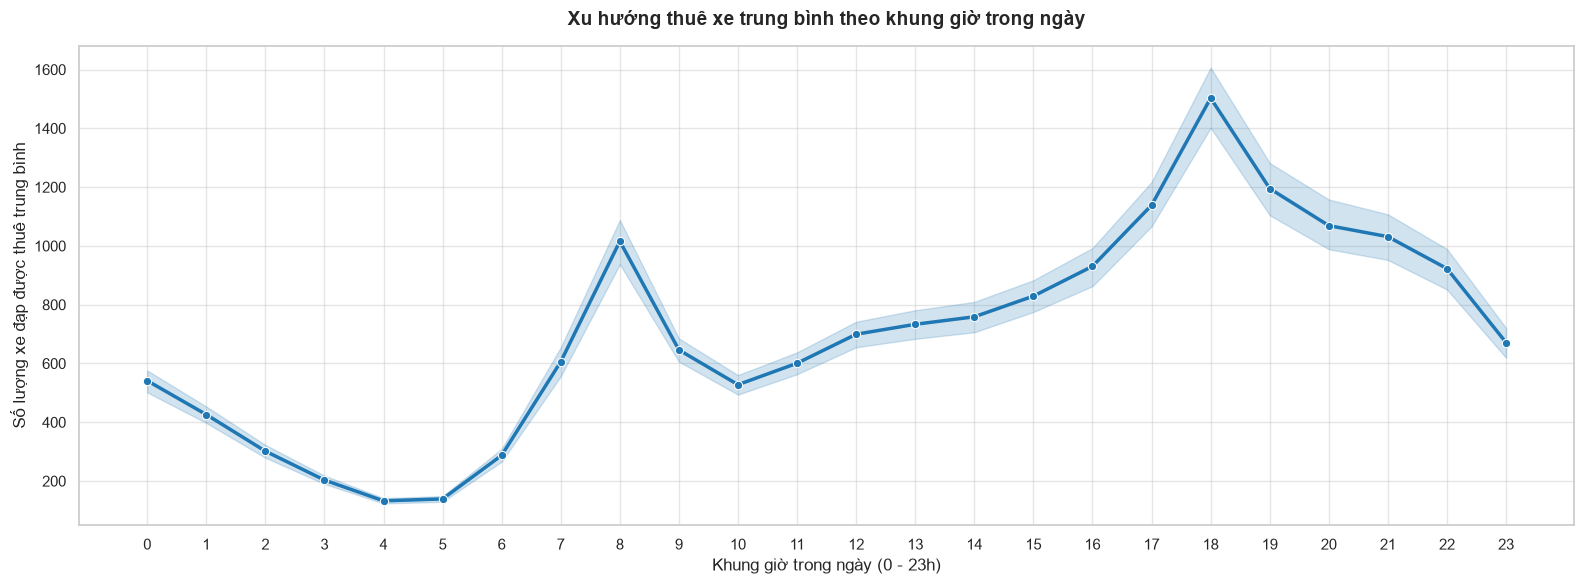

In [25]:

plt.figure(figsize=(16, 6))
# Vẽ Line plot (tự động tính Mean và 95% Confidence Interval)
sns.lineplot(
    data=df,
    x="hour",
    y="rented_bike_count",
    marker="o",
    linewidth=2.5,
    markersize=6,
    color="#1f77b4",
    errorbar=("ci", 95),  # Dải bóng mờ thể hiện khoảng tin cậy 95%
)

# Tinh chỉnh tiêu đề và các trục
plt.title(
    "Xu hướng thuê xe trung bình theo khung giờ trong ngày",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Khung giờ trong ngày (0 - 23h)", fontsize=12)
plt.ylabel("Số lượng xe đạp được thuê trung bình", fontsize=12)
plt.xticks(range(0, 24))  # Hiển thị đầy đủ 24 mốc giờ từ 0 đến 23

plt.tight_layout()
plt.show()

- chú thích:
    - Thông quá biểu đồ này cho ta thấy mối quan hệ giăux giờ và thuê xe là mối quan hệ phi tuyến tính lên xuông thất thường
    - Lượng thuê tăng mạnh từ lúc 5h - 8h và từ 10h đê 18h
    - Đạt đỉnh vào lúc 8 giờ và 18 có thể đó là thời gian đi làm và tan ca

#### 3.3.2 Bike rental theo ngày trong tuần

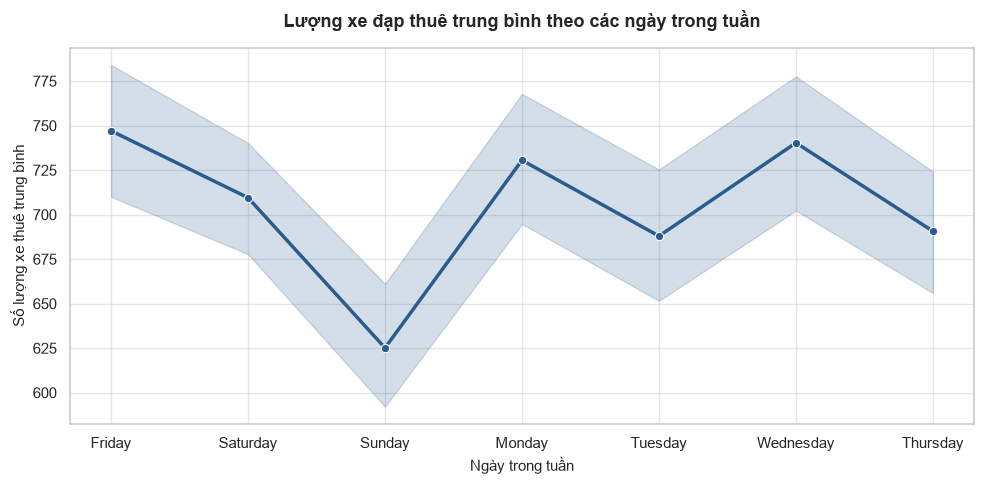

In [26]:
df["day_name"] = df["date"].dt.day_name()

# Vẽ biểu đồ nhu cầu thuê xe trung bình theo ngày trong tuần
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="day_name",
    y="rented_bike_count",
    sort=False,
    marker="o",
    linewidth=2.5,
    color="#2b5c8f",
    errorbar=("ci", 95),
)

plt.title(
    "Lượng xe đạp thuê trung bình theo các ngày trong tuần",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Ngày trong tuần", fontsize=11)
plt.ylabel("Số lượng xe thuê trung bình", fontsize=11)
plt.tight_layout()
plt.show()

- chú thích:
    - Môi quan hệ giữa ngày trong tuần và số lượng thuê phi tuyến tính
    - Và cũng khẳng định là người dân seoul thuê xe để đi làm vì số lượng thuê xe ở thứ 7 cn giảm rất mạnh

#### 3.4.3 Bike rental theo tháng / mùa

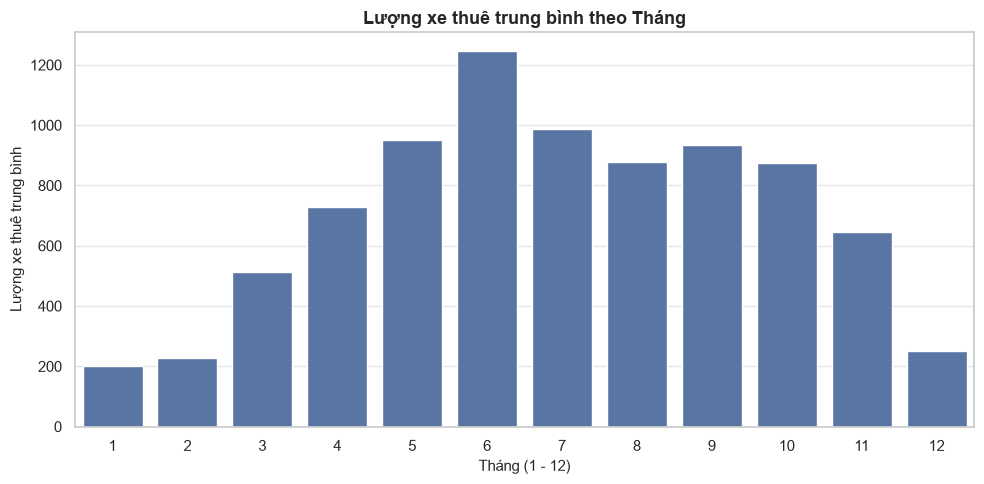

In [27]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# --- Biểu đồ 1: Lượng xe thuê trung bình theo Tháng ---
month_order = range(1, 13)
sns.barplot(
    data=df,
    x="month",
    y="rented_bike_count",
    order=month_order,
    legend=False,
    errorbar=None,
)
plt.title(
    "Lượng xe thuê trung bình theo Tháng", fontsize=13, fontweight="bold"
)
plt.xlabel("Tháng (1 - 12)", fontsize=11)
plt.ylabel("Lượng xe thuê trung bình", fontsize=11)

plt.tight_layout()
plt.show()


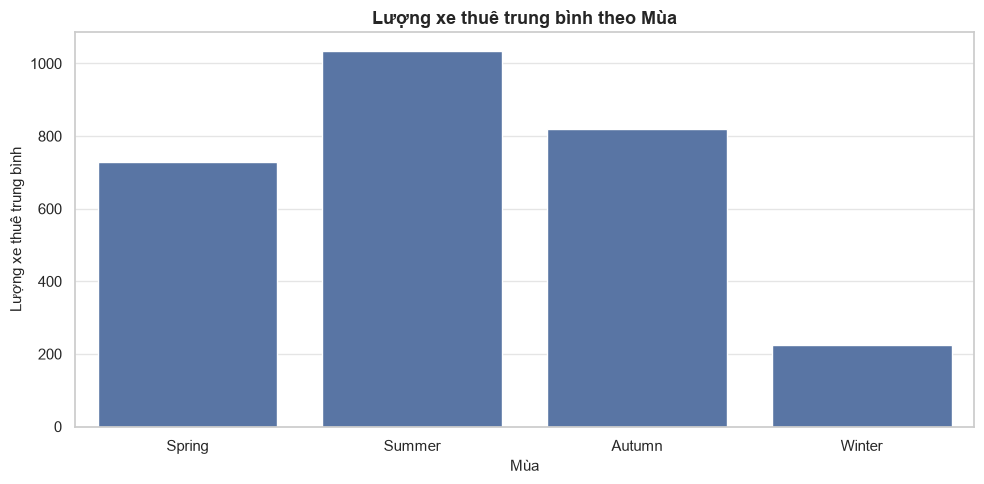

In [28]:
# --- Biểu đồ 2: Lượng xe thuê trung bình theo Mùa ---
plt.figure(figsize=(10, 5))

season_order = ["Spring", "Summer", "Autumn", "Winter"]
sns.barplot(
    data=df,
    x="seasons",
    y="rented_bike_count",
    order=season_order,
    legend=False,
    errorbar=None,
)
plt.title(
    "Lượng xe thuê trung bình theo Mùa", fontsize=13, fontweight="bold"
)
plt.xlabel("Mùa", fontsize=11)
plt.ylabel("Lượng xe thuê trung bình", fontsize=11)

plt.tight_layout()
plt.show()

#### 3.4.4 Xu hướng theo thời gian (tổng theo ngày)

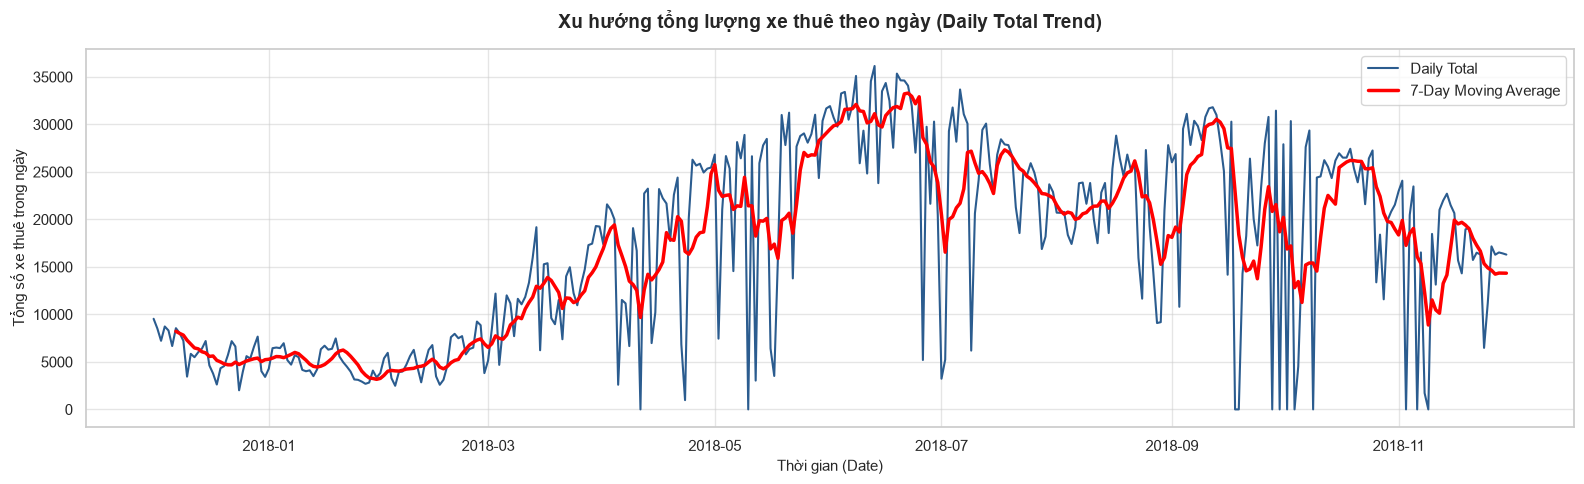

In [29]:
# --- Biểu đồ 3: Xu hướng tổng theo ngày (Daily Total Time-Series) ---
daily_df = (
    df.groupby("date")["rented_bike_count"].sum().reset_index()
)  # Gom tổng 24h thành 1 ngày

plt.figure(figsize=(16, 5))
plt.plot(
    daily_df["date"],
    daily_df["rented_bike_count"],
    color="#2b5c8f",
    linewidth=1.5,
    label="Daily Total",
)

# Thêm đường Rolling Average 7 ngày để làm mượt xu hướng (Trend Smooth)
daily_df["7D_MA"] = daily_df["rented_bike_count"].rolling(window=7).mean()
plt.plot(
    daily_df["date"],
    daily_df["7D_MA"],
    color="red",
    linewidth=2.5,
    label="7-Day Moving Average",
)

plt.title(
    "Xu hướng tổng lượng xe thuê theo ngày (Daily Total Trend)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Thời gian (Date)", fontsize=11)
plt.ylabel("Tổng số xe thuê trong ngày", fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

- Chú thích:
    - tháng với lượng xe thuê cug phi tuyến tính
    - Lượng xe thuê nhiều nhất vào mùa hè

### 3.4.5 Xú hướng theo giờ thuê xe vào chủ nhât

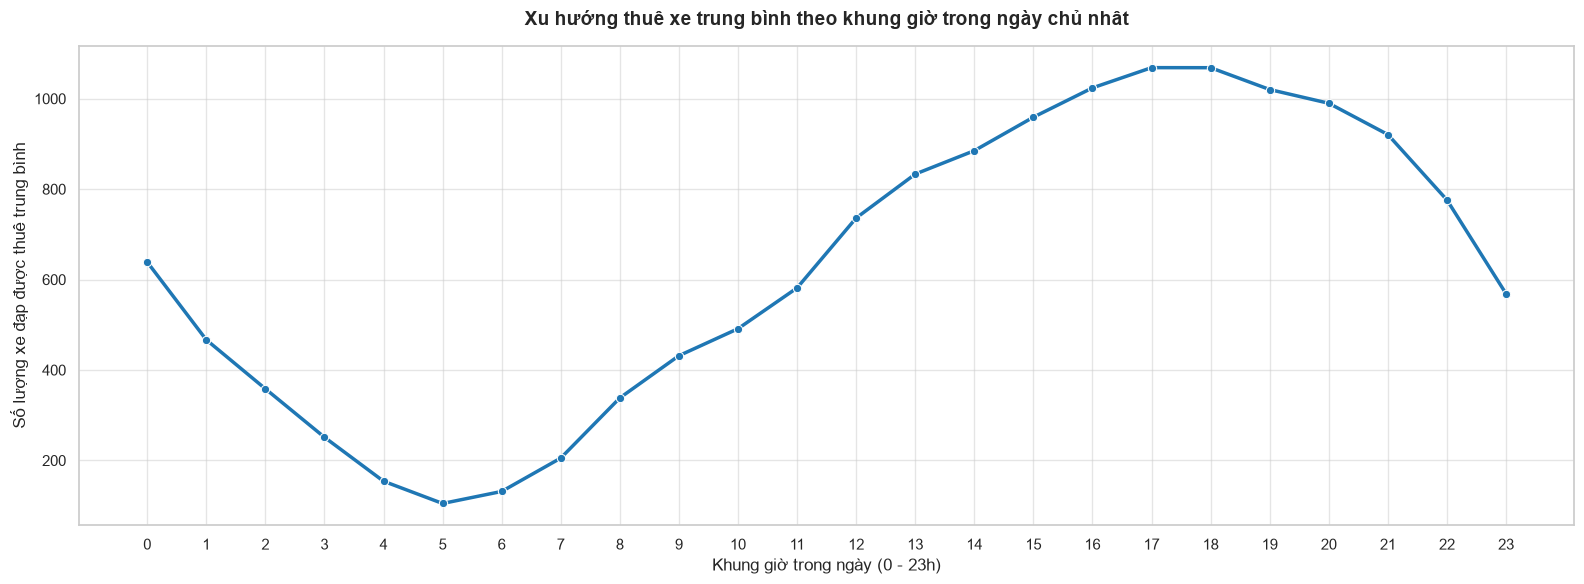

In [30]:
weekend_df = df.loc[df['is_weekend']==True].groupby('hour').agg({
    "rented_bike_count":"mean"
}).reset_index()

plt.figure(figsize=(16, 6))
# Vẽ Line plot (tự động tính Mean và 95% Confidence Interval)
sns.lineplot(
    data=weekend_df,
    x="hour",
    y="rented_bike_count",
    marker="o",
    linewidth=2.5,
    markersize=6,
    color="#1f77b4",
    errorbar=("ci", 95),  # Dải bóng mờ thể hiện khoảng tin cậy 95%
)

# Tinh chỉnh tiêu đề và các trục
plt.title(
    "Xu hướng thuê xe trung bình theo khung giờ trong ngày chủ nhât",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Khung giờ trong ngày (0 - 23h)", fontsize=12)
plt.ylabel("Số lượng xe đạp được thuê trung bình", fontsize=12)
plt.xticks(range(0, 24))  # Hiển thị đầy đủ 24 mốc giờ từ 0 đến 23

plt.tight_layout()
plt.show()

- Chú thích:
    - Theo xu hưởng khung giờ mượn xe vào chủ nhật thì tăng liên tục từ 5 - 18h khả năng cao là đi chơi còn ngày thường thì chỉ tập trùng vào 8 và 18 h thôi

### 3.5 Weather Impact Analysis

#### 3.5.1 Bike rental theo từng mức Temperature (bin) Ảnh hưởng của Rainfall, Snowfall đến rental count, So sánh ngày Holiday vs Non-holiday

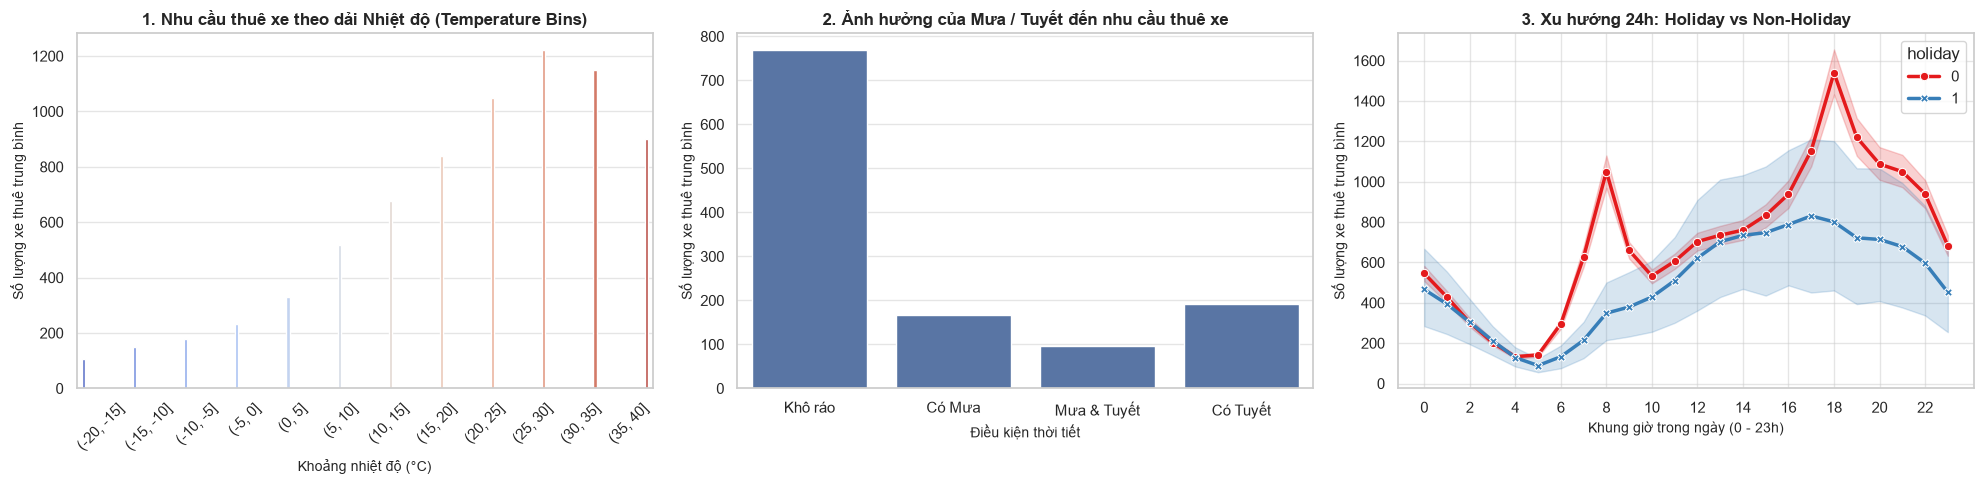

In [31]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Bike rental theo từng mức Temperature (Binning)
# Chia nhiệt độ thành các khoảng 5 độ C
df['temp_bin'] = pd.cut(df['temperature'], bins=range(-20, 45, 5))

sns.barplot(
    data=df,
    x='temp_bin',
    y='rented_bike_count',
    hue='temp_bin',
    legend=False,
    palette='coolwarm',
    ax=axes[0],
    errorbar=None,
)
axes[0].set_title(
    '1. Nhu cầu thuê xe theo dải Nhiệt độ (Temperature Bins)',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_xlabel('Khoảng nhiệt độ (°C)', fontsize=10)
axes[0].set_ylabel('Số lượng xe thuê trung bình', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# 2. Ảnh hưởng của Rainfall / Snowfall đến Rental Count
# Tạo nhãn phân loại: Không mưa/tuyết, Có mưa, Có tuyết
conditions = [
    (df['rainfall'] > 0) & (df['snowfall'] == 0),
    (df['snowfall'] > 0) & (df['rainfall'] == 0),
    (df['rainfall'] > 0) & (df['snowfall'] > 0),
    (df['rainfall'] == 0) & (df['snowfall'] == 0),
]
choices = ['Có Mưa', 'Có Tuyết', 'Mưa & Tuyết', 'Khô ráo']
df['weather_condition'] = np.select(
    conditions, choices, default='Khô ráo'
)

sns.barplot(
    data=df,
    x='weather_condition',
    y='rented_bike_count',
    legend=False,
    ax=axes[1],
    errorbar=None,
)
axes[1].set_title(
    '2. Ảnh hưởng của Mưa / Tuyết đến nhu cầu thuê xe',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_xlabel('Điều kiện thời tiết', fontsize=10)
axes[1].set_ylabel('Số lượng xe thuê trung bình', fontsize=10)

# 3. So sánh ngày Holiday vs Non-holiday (kết hợp 24h)
sns.lineplot(
    data=df,
    x='hour',
    y='rented_bike_count',
    hue='holiday',
    style='holiday',
    palette='Set1',
    linewidth=2.5,
    markers=True,
    dashes=False,
    ax=axes[2],
)
axes[2].set_title(
    '3. Xu hướng 24h: Holiday vs Non-Holiday',
    fontsize=12,
    fontweight='bold',
)
axes[2].set_xlabel('Khung giờ trong ngày (0 - 23h)', fontsize=10)
axes[2].set_ylabel('Số lượng xe thuê trung bình', fontsize=10)
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

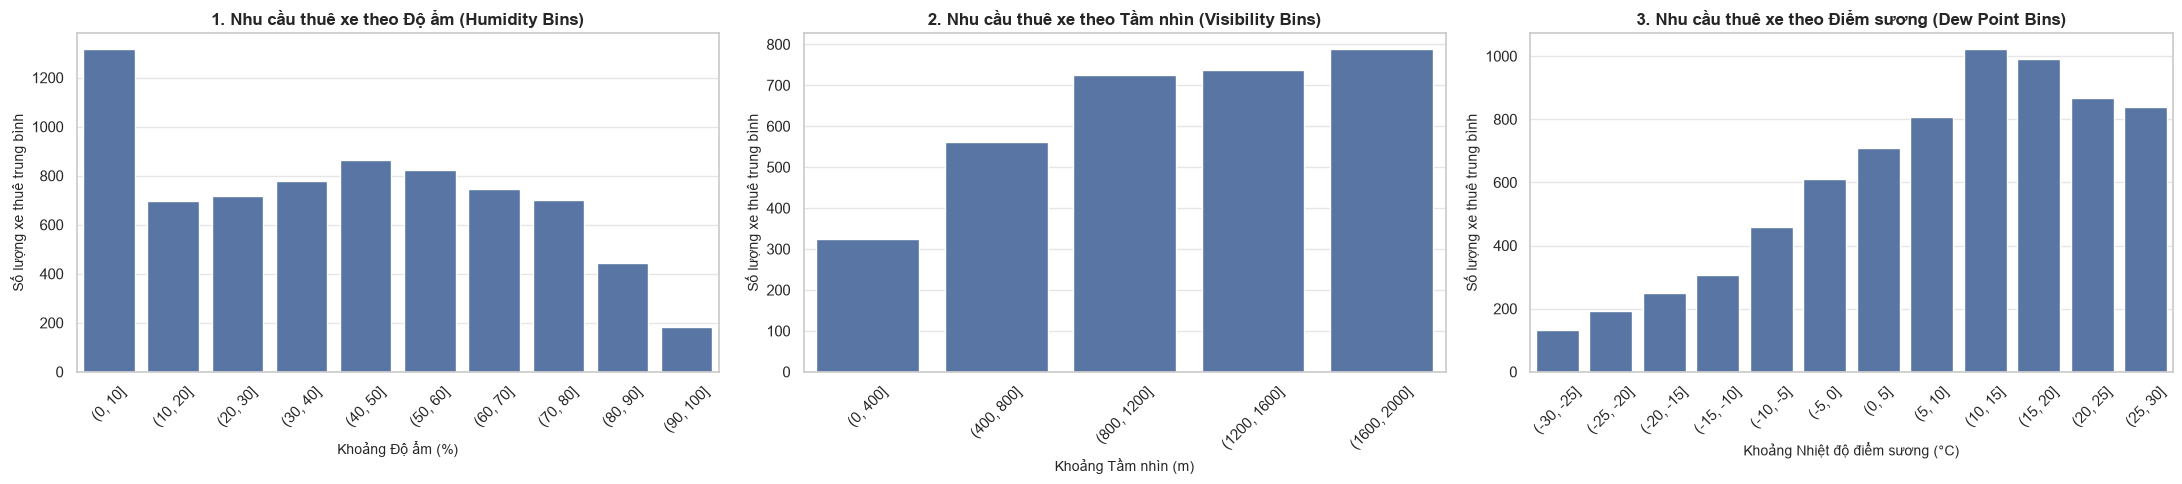

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots for Humidity, Visibility, Dew Point
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# -------------------------------------------------------------------
# 1. HUMIDITY (Độ ẩm %) - Binning theo khoảng 10%
# -------------------------------------------------------------------
df["humidity_bin"] = pd.cut(df["humidity"], bins=range(0, 110, 10))

sns.barplot(
    data=df,
    x="humidity_bin",
    y="rented_bike_count",
    legend=False,
    ax=axes[0],
    errorbar=None,
)
axes[0].set_title(
    "1. Nhu cầu thuê xe theo Độ ẩm (Humidity Bins)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Khoảng Độ ẩm (%)", fontsize=10)
axes[0].set_ylabel("Số lượng xe thuê trung bình", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)

# -------------------------------------------------------------------
# 2. VISIBILITY (Tầm nhìn m) - Binning theo khoảng 400m
# -------------------------------------------------------------------
df["visibility_bin"] = pd.cut(df["visibility"], bins=range(0, 2400, 400))

sns.barplot(
    data=df,
    x="visibility_bin",
    y="rented_bike_count",
    legend=False,
    ax=axes[1],
    errorbar=None,
)
axes[1].set_title(
    "2. Nhu cầu thuê xe theo Tầm nhìn (Visibility Bins)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Khoảng Tầm nhìn (m)", fontsize=10)
axes[1].set_ylabel("Số lượng xe thuê trung bình", fontsize=10)
axes[1].tick_params(axis="x", rotation=45)

# -------------------------------------------------------------------
# 3. DEW POINT TEMPERATURE (Nhiệt độ điểm sương °C) - Binning khoảng 5°C
# -------------------------------------------------------------------
df["dew_bin"] = pd.cut(
    df["dew_point_temperature"], bins=range(-30, 35, 5)
)

sns.barplot(
    data=df,
    x="dew_bin",
    y="rented_bike_count",
    legend=False,
    ax=axes[2],
    errorbar=None,
)
axes[2].set_title(
    "3. Nhu cầu thuê xe theo Điểm sương (Dew Point Bins)",
    fontsize=12,
    fontweight="bold",
)
axes[2].set_xlabel("Khoảng Nhiệt độ điểm sương (°C)", fontsize=10)
axes[2].set_ylabel("Số lượng xe thuê trung bình", fontsize=10)
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- Chú thích:
    - Tầm nhìn càng xa thì càng có nhiều người tới thuê xe

#### 3.5.2 Nhu cầu thuê xe theo năng lượng mặt trời

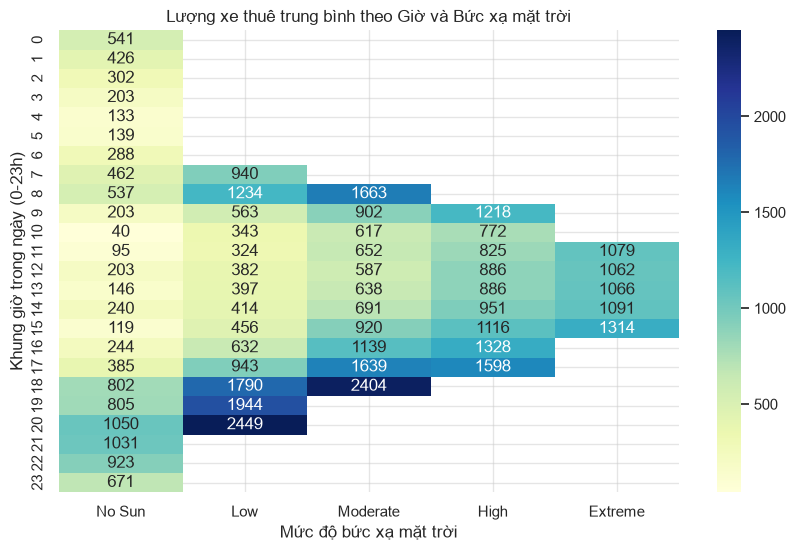

In [33]:

# 1. Feature Engineering: Binning solar radiation if not already present
df["solar_bin"] = pd.cut(
    df["solar_radiation"],
    bins=[-np.inf, 0.1, 1.0, 2.0, 3.0, np.inf],
    labels=["No Sun", "Low", "Moderate", "High", "Extreme"],
)
# 1. Vẽ Heatmap tương quan giữa Giờ trong ngày x Bức xạ mặt trời
pivot_df = df.pivot_table(
    index="hour", columns="solar_bin", values="rented_bike_count", aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Lượng xe thuê trung bình theo Giờ và Bức xạ mặt trời")
plt.xlabel("Mức độ bức xạ mặt trời")
plt.ylabel("Khung giờ trong ngày (0-23h)")
plt.show()

- Chú thích:
    - Nhiệt đố càng cao thì sẽ có nhiều người thuê xe hơn
    - Điều kiện thời tiết kho ráo là tốt nhất
    - Ngày thường sẽ có nhiều người thuê xe hơn
    - Bức xạ càng lớn thì sẽ có nhiều ngươi đi xe hơn nhưng chủ yếu vẫn phụ thuộc vào giờ cao hơn

#### 3.6 Outlier Detection

#### 3.6.1 Boxplot toàn bộ numerical features


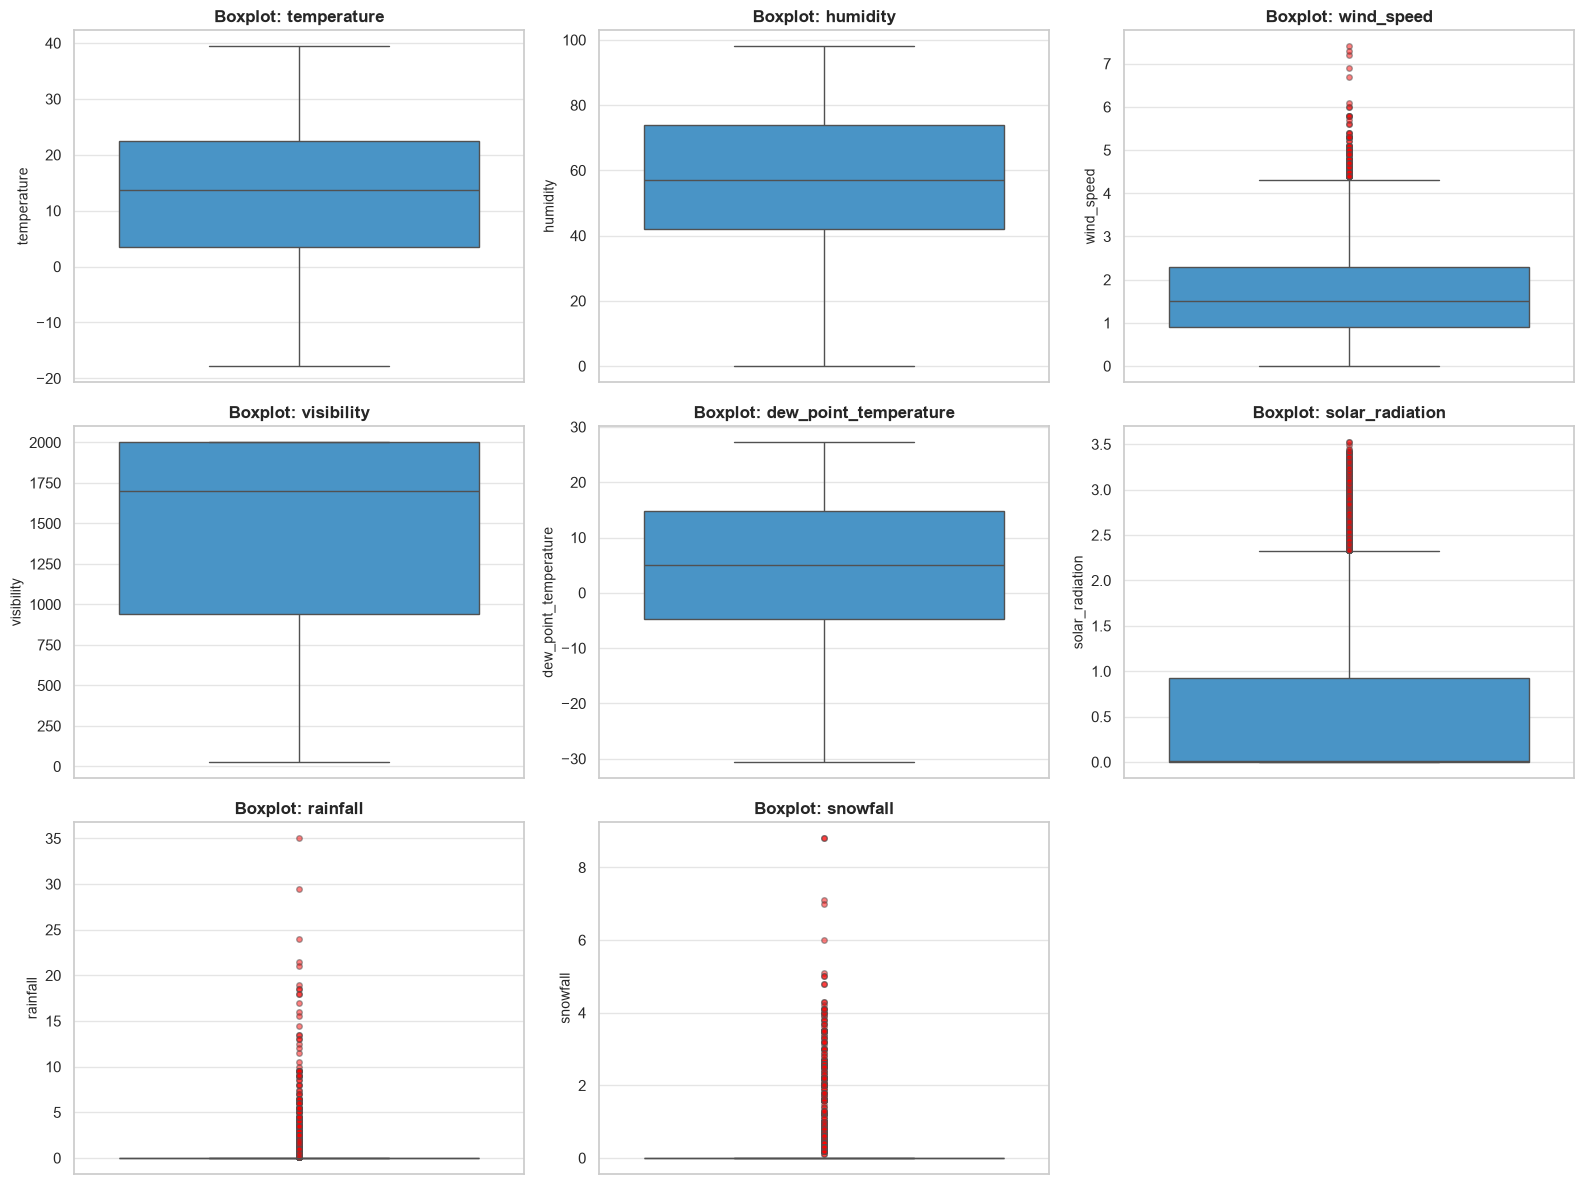

In [34]:
import math
# 2. Cấu hình lưới Subplots tự động
n_features = len(num_cols_not_target)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# 3. Vẽ Boxplot cho từng feature (sử dụng hue để tránh cảnh báo Seaborn >=0.14)
for i, col in enumerate(num_cols_not_target):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="#3498db",
        flierprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markersize": 4,
            "alpha": 0.5,
        },
    )
    axes[i].set_title(f"Boxplot: {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(col, fontsize=10)

# Ẩn các ô thừa trên lưới
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 3.6.2 Z-score hoặc IQR method để identify outliers

In [35]:
import pandas as pd
from scipy import stats
def detect_outliers_report(df, features, iqr_factor=1.5, z_threshold=3.0):
    """Báo cáo so sánh Outliers giữa phương pháp IQR và Z-Score."""
    report = []
    total_rows = len(df)

    for col in features:
        # --- 1. Phương pháp IQR ---
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (iqr_factor * iqr)
        upper_bound = q3 + (iqr_factor * iqr)

        iqr_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        iqr_count = len(iqr_outliers)

        # --- 2. Phương pháp Z-Score ---
        # Tính z-score loại bỏ giá trị NaN nếu có
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        z_count = (z_scores > z_threshold).sum()

        report.append(
            {
                "Feature": col,
                "IQR Outliers (Count)": iqr_count,
                "IQR Outliers (%)": round((iqr_count / total_rows) * 100, 2),
                "Z-Score Outliers (Count)": z_count,
                "Z-Score Outliers (%)": round((z_count / total_rows) * 100, 2),
            }
        )

    return pd.DataFrame(report)


# Chạy kiểm tra trên các features đã chọn
outlier_summary = detect_outliers_report(df, num_cols_not_target)
print(outlier_summary.to_string(index=False))

              Feature  IQR Outliers (Count)  IQR Outliers (%)  Z-Score Outliers (Count)  Z-Score Outliers (%)
          temperature                     0              0.00                         0                  0.00
             humidity                     0              0.00                         0                  0.00
           wind_speed                   161              1.84                        63                  0.72
           visibility                     0              0.00                         0                  0.00
dew_point_temperature                     0              0.00                         0                  0.00
      solar_radiation                   641              7.32                        85                  0.97
             rainfall                   528              6.03                        94                  1.07
             snowfall                   443              5.06                       173                  1.97


### 3.6 Tạo Feature

In [36]:
# Vì snowfall phân phối ko chuẩn nên tui tạo ra biến is_snow
df["is_snow"] = np.where(df["snowfall"] > 0, 1, 0)
df['is_snow'] = df['is_snow'].astype('category')

In [37]:
# Vì rainfall phân phối ko chuẩn nên tui tạo ra biến is_rain
df["is_rain"] = np.where(df["rainfall"] > 0, 1, 0)
df['is_rain'] = df['is_rain'].astype('category')

In [38]:
# Tầm nhìn dưới 500m được coi là sương mù/tầm nhìn xấu
df["is_low_visibility"] = (df["visibility"] < 500).astype(int)
df["is_sunny"] = (df["solar_radiation"] > 0).astype(int)
df["is_low_visibility"] = df['is_low_visibility'].astype('category')
df["is_sunny"] = df['is_sunny'].astype('category')

In [39]:
import numpy as np
import pandas as pd


def encode_cyclical_features(df):
    """Mã hóa chu kỳ Sin/Cos cho các biến thời gian."""
    df_feat = df.copy()

    # 1. Hour (Chu kỳ 24h)
    df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"].astype('int') / 24.0)
    df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"].astype('int') / 24.0)

    # 2. Month (Chu kỳ 12 tháng)
    df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"].astype('int') / 12.0)
    df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"].astype('int') / 12.0)

    # 3. Weekday (Chu kỳ 7 ngày)
    if "weekday" in df_feat.columns:
        df_feat["weekday_sin"] = np.sin(2 * np.pi * df_feat["weekday"].astype('int') / 7.0)
        df_feat["weekday_cos"] = np.cos(2 * np.pi * df_feat["weekday"].astype('int') / 7.0)

    return df_feat

df = encode_cyclical_features(df)


### 3.7 Feature Correlation & Selection

In [40]:
# 1. Biến Continuous (Thêm các biến Sin/Cos vào đây)
num_cols = [
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos",
]

# 2. Biến Categoricals (Đã loại bỏ hour, month, weekday gốc)
cat_cols = [
    "seasons",
    "holiday",
    "functioning_day",
    "is_weekend",
    "is_snow",
    "is_rain",
    "is_sunny",
    "is_low_visibility",
]

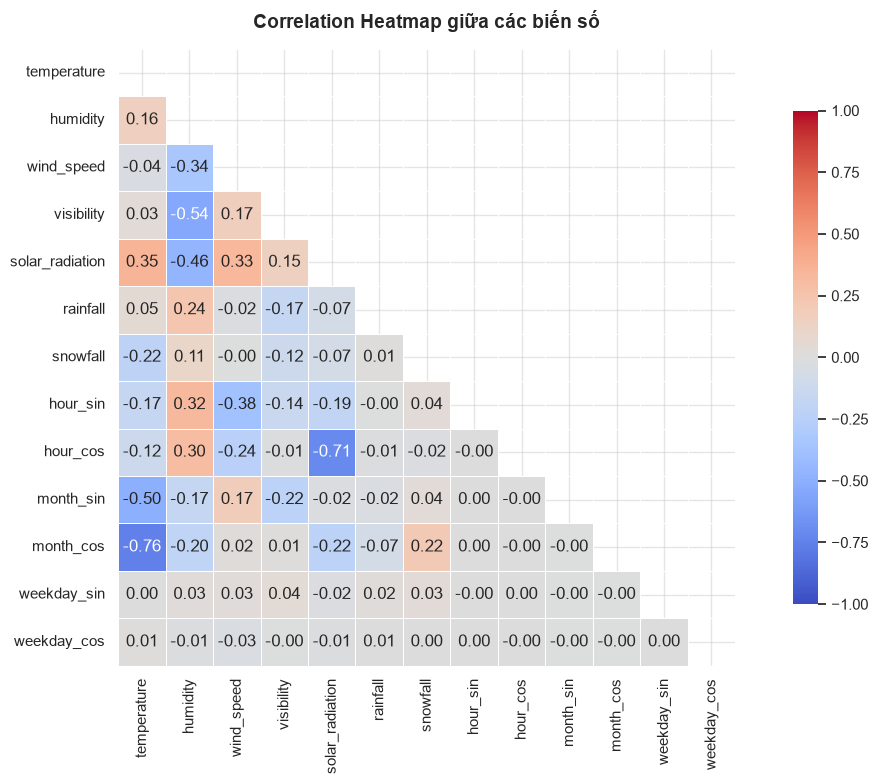

In [41]:
corr_matrix = df[num_cols].corr()

# 3. Tạo mask để che bớt nửa trên tam giác (giúp biểu đồ gọn, không bị lặp thông tin)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Vẽ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Correlation Heatmap giữa các biến số", fontsize=14, fontweight="bold", pad=15
)
plt.tight_layout()
plt.show()

In [42]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor


# -------------------------------------------------------------------
# BƯỚC 1: ANOVA TEST (Categorical Feature vs Continuous Target)
# -------------------------------------------------------------------
def feature_selection_anova(df, cat_cols, target_col, alpha=0.05):
    """Lọc các biến Categorical có ảnh hưởng tới Target Continuous bằng One-way ANOVA."""
    selected_cats = []
    anova_results = []

    for col in cat_cols:
        groups = [
            group[target_col].dropna().values
            for _, group in df.groupby(col, observed=True)
        ]

        if len(groups) <= 1:
            continue

        f_stat, p_val = stats.f_oneway(*groups)
        is_selected = p_val < alpha

        if is_selected:
            selected_cats.append(col)

        anova_results.append(
            {
                "Feature": col,
                "F-Statistic": round(f_stat, 4),
                "p-value": p_val,
                "Passed_ANOVA": is_selected,
            }
        )

    anova_df = pd.DataFrame(anova_results).sort_values(
        by="F-Statistic", ascending=False
    )
    return selected_cats, anova_df.reset_index(drop=True)


# -------------------------------------------------------------------
# BƯỚC 2: VIF + PHI TUYẾN TÍNH CORRELATION (Num vs Num & Cat vs Num)
# -------------------------------------------------------------------
def _correlation_ratio(categories, measurements):
    """Tính Correlation Ratio (Eta) từ ANOVA SSB/SST cho Cat vs Num."""
    categories = np.asarray(categories)
    measurements = np.asarray(measurements)

    valid_mask = ~pd.isna(categories) & ~pd.isna(measurements)
    categories, measurements = (
        categories[valid_mask],
        measurements[valid_mask],
    )

    if len(measurements) == 0:
        return 0.0

    ss_total = np.sum((measurements - np.mean(measurements)) ** 2)
    if ss_total == 0:
        return 0.0

    unique_cats = np.unique(categories)
    ss_between = sum(
        len(measurements[categories == cat])
        * ((np.mean(measurements[categories == cat]) - np.mean(measurements)) ** 2)
        for cat in unique_cats
    )

    return np.sqrt(ss_between / ss_total)


def calculate_comprehensive_vif_and_corr(
    df, selected_cat_cols=None, num_cols=None, vif_threshold=5.0, corr_threshold=0.7
):
    """Tính Safe VIF và Ma trận tương quan phi tuyến (Spearman & Correlation Ratio)."""
    num_cols = list(num_cols) if num_cols is not None else []
    selected_cat_cols = (
        list(selected_cat_cols) if selected_cat_cols is not None else []
    )
    all_features = num_cols + selected_cat_cols

    if not all_features:
        raise ValueError("Danh sách features rỗng.")

    # 1. Tính Tương quan Phi tuyến giữa các cặp biến
    n_feats = len(all_features)
    corr_matrix = pd.DataFrame(
        np.ones((n_feats, n_feats)), index=all_features, columns=all_features
    )

    for i in range(n_feats):
        for j in range(i + 1, n_feats):
            c1, c2 = all_features[i], all_features[j]

            # Continuous vs Continuous -> Spearman
            if c1 in num_cols and c2 in num_cols:
                val = abs(stats.spearmanr(df[c1], df[c2])[0])
            # Categorical vs Continuous -> Correlation Ratio (Eta)
            else:
                cat_var = c1 if c1 in selected_cat_cols else c2
                num_var = c2 if c1 in selected_cat_cols else c1
                val = _correlation_ratio(df[cat_var], df[num_var])

            corr_matrix.loc[c1, c2] = val
            corr_matrix.loc[c2, c1] = val

    # 2. Tạo Feature Matrix cho VIF (One-Hot Encoding)
    feature_df = pd.DataFrame()
    if num_cols:
        feature_df = df[num_cols].copy()

    if selected_cat_cols:
        df_encoded = pd.get_dummies(
            df[selected_cat_cols],
            columns=selected_cat_cols,
            drop_first=True,
            dtype=int,
        )
        feature_df = pd.concat([feature_df, df_encoded], axis=1)

    feature_df = feature_df.loc[:, feature_df.nunique() > 1]
    feature_df["intercept"] = 1.0

    # 3. Tính Safe VIF và tổng hợp kết quả
    vif_results = []
    features_vif = [c for c in feature_df.columns if c != "intercept"]

    for col in features_vif:
        try:
            col_idx = feature_df.columns.get_loc(col)
            vif_val = variance_inflation_factor(feature_df.values, col_idx)
        except Exception:
            vif_val = np.inf

        # Map tên cột OHE về tên biến gốc
        base_feature = col
        for cat in selected_cat_cols:
            if col.startswith(cat + "_"):
                base_feature = cat
                break

        other_corrs = corr_matrix[base_feature].drop(index=base_feature)
        max_corr_val = other_corrs.max() if not other_corrs.empty else 0.0
        max_corr_feat = other_corrs.idxmax() if not other_corrs.empty else "None"

        vif_results.append(
            {
                "Encoded_Feature": col,
                "Base_Feature": base_feature,
                "VIF": round(vif_val, 2) if not np.isinf(vif_val) else np.inf,
                "Max_NonLinear_Corr": round(max_corr_val, 2),
                "Most_Correlated_With": max_corr_feat,
                "High_Multicollinearity": (vif_val >= vif_threshold)
                or (max_corr_val >= corr_threshold),
            }
        )

    return pd.DataFrame(vif_results).sort_values(by="VIF", ascending=False).reset_index(drop=True)

In [44]:
# Bước 1: Chạy ANOVA cho các biến Categorical với Target rented_bike_count
selected_cats, anova_summary = feature_selection_anova(
    df=df,
    cat_cols=cat_cols,
    target_col="rented_bike_count",
    alpha=0.05,
)

# Bước 2: Đẩy các biến Cat vượt qua ANOVA + các biến Num vào VIF & Corr
vif_summary = calculate_comprehensive_vif_and_corr(
    df=df,
    selected_cat_cols=selected_cats,
    num_cols=num_cols,
    vif_threshold=5.0,
    corr_threshold=0.7,
)

vif_summary

,Encoded_Feature,Base_Feature,VIF,Max_NonLinear_Corr,Most_Correlated_With,High_Multicollinearity
0,temperature,temperature,10.25,0.86,seasons,True
1,month_sin,month_sin,9.68,0.91,seasons,True
2,seasons_Spring,seasons,9.47,0.91,month_cos,True
3,month_cos,month_cos,9.28,0.91,seasons,True
4,hour_cos,hour_cos,5.98,0.86,solar_radiation,True
5,seasons_Summer,seasons,5.67,0.91,month_cos,True
6,seasons_Winter,seasons,5.54,0.91,month_cos,True
7,is_sunny_1,is_sunny,4.59,0.84,hour_cos,True
8,solar_radiation,solar_radiation,3.46,0.86,hour_cos,True
9,humidity,humidity,3.17,0.48,visibility,False


###  4. Train model

### 5. Đánh giá model